# The page and the panel

Matplotlib gives you two objects, and the names matter.

- The **Figure** is the page.
- The **Axes** is one panel on that page. It owns the marks, the ticks, and the labels.

Keep both names in variables:

```python
fig, ax = plt.subplots()
ax.plot(days, totals)
```

Draw on `ax`. Decorate `ax`. Save `fig`. The function `plt.plot`, with no axes in your hand, draws on whatever panel happens to be current. With one panel you will not notice. With two panels it puts the line in the wrong place.


## One panel, checked

Use the daily totals again: $18, 20, 22, 24, 26$. Thursday is the fourth point and its value is $24$. After one `ax.plot`, the panel holds one line. The page holds one panel.


page Figure panels 1 lines 1


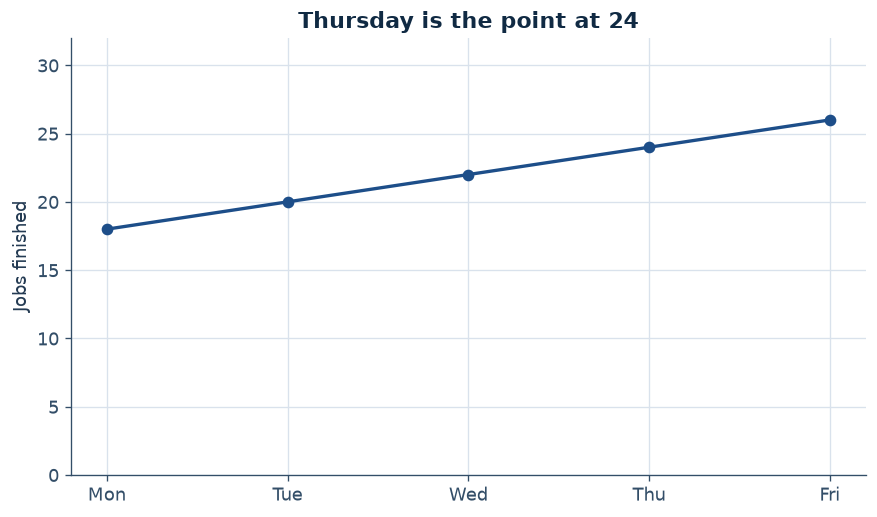

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# fig is the page. ax is the only panel. One plot call leaves one line.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
totals = [18, 20, 22, 24, 26]
fig, ax = plt.subplots(constrained_layout=True)
ax.plot(days, totals, color=BLUE, marker="o", linewidth=2)
ax.set_ylabel("Jobs finished")
ax.set_ylim(0, 32)
ax.set_title("Thursday is the point at 24")
assert type(fig).__name__ == "Figure"
assert type(ax).__name__ == "Axes"
assert len(fig.axes) == 1
assert len(ax.lines) == 1
assert list(ax.lines[0].get_ydata()) == totals
print("page", type(fig).__name__, "panels", len(fig.axes), "lines", len(ax.lines))


## One change: a second call adds a second line

Ada's row is $4, 5, 5, 6, 7$. Plotting it on the same axes does not create a new page. It adds a line to the panel you already have. The panel's line count goes from $1$ to $2$.


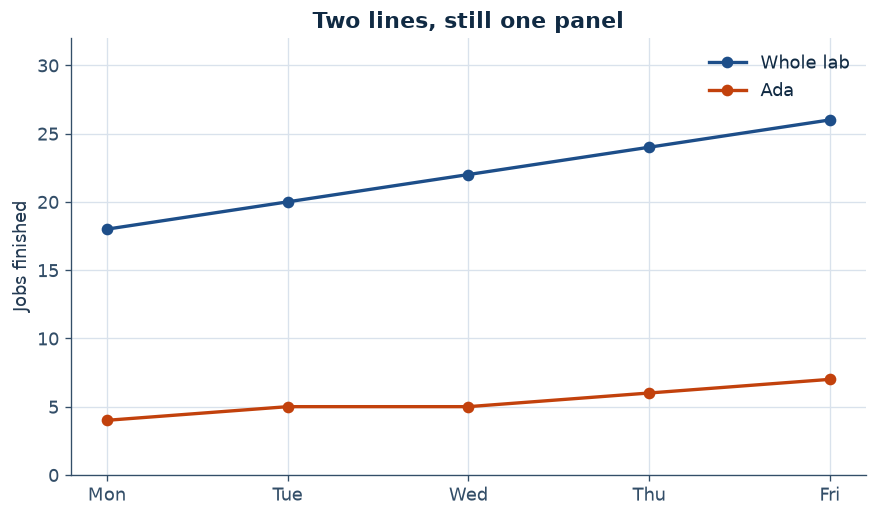

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# A second ax.plot on the same panel adds a line. It does not open a new page.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
totals = [18, 20, 22, 24, 26]
ada = [4, 5, 5, 6, 7]
fig, ax = plt.subplots(constrained_layout=True)
ax.plot(days, totals, color=BLUE, marker="o", linewidth=2, label="Whole lab")
ax.plot(days, ada, color=CLAY, marker="o", linewidth=2, label="Ada")
ax.set_ylabel("Jobs finished")
ax.set_ylim(0, 32)
ax.legend(frameon=False)
ax.set_title("Two lines, still one panel")
assert len(fig.axes) == 1
assert len(ax.lines) == 2
assert list(ax.lines[1].get_ydata()) == ada


## Where a bare `plt.plot` lands

Two panels, side by side. The left panel was meant for the daily totals. This call never mentions either panel:

```python
plt.plot(days, totals)
```

Matplotlib draws on the current axes, and the current axes is the last one created. The left panel stays empty. The right panel receives a line it was not assigned.


left lines 0 right lines 1


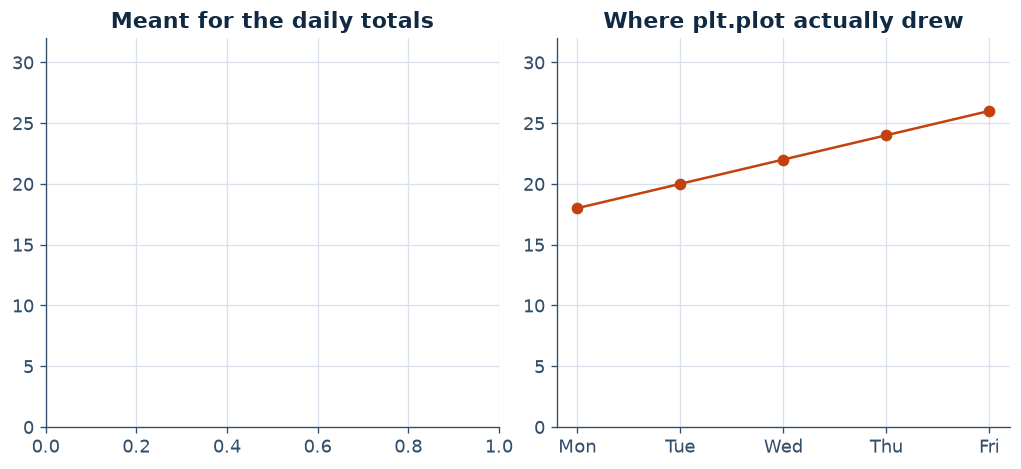

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# plt.plot with no axes uses the last panel. The left panel stays empty.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
totals = [18, 20, 22, 24, 26]
fig, panels = plt.subplots(1, 2, constrained_layout=True, figsize=(8.4, 3.8))
plt.plot(days, totals, color=CLAY, marker="o")
panels[0].set_title("Meant for the daily totals")
panels[1].set_title("Where plt.plot actually drew")
panels[0].set_ylim(0, 32)
panels[1].set_ylim(0, 32)
assert len(panels[0].lines) == 0
assert len(panels[1].lines) == 1
print("left lines", len(panels[0].lines), "right lines", len(panels[1].lines))


## The repair

Say which panel you mean.

```python
panels[0].plot(days, totals)
```

The right panel can then take a different question, such as the four weekly totals. Each panel has one job, and each mark was sent to a panel by name.


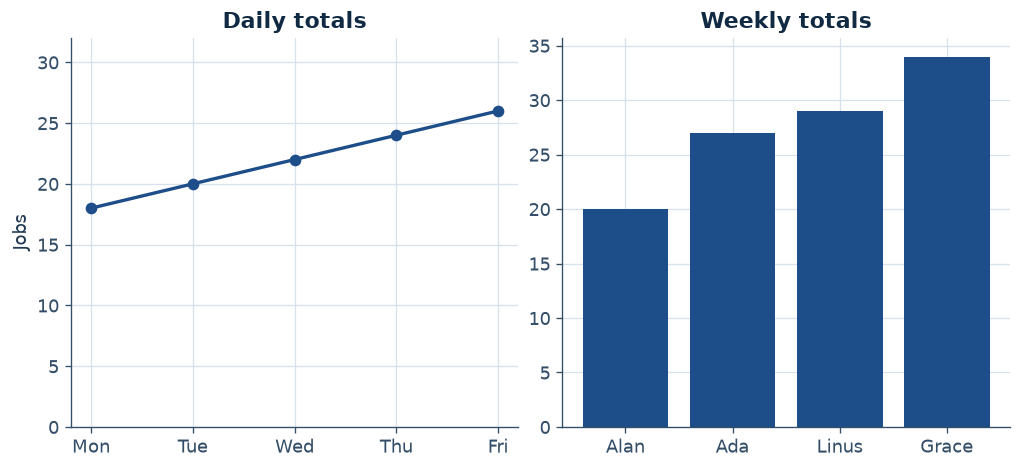

In [4]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Name the panel. The line stays on the left. The bars stay on the right.
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
totals = [18, 20, 22, 24, 26]
fig, panels = plt.subplots(1, 2, constrained_layout=True, figsize=(8.4, 3.8))
panels[0].plot(days, totals, color=BLUE, marker="o", linewidth=2)
panels[0].set_ylim(0, 32)
panels[0].set_title("Daily totals")
panels[0].set_ylabel("Jobs")
panels[1].bar(["Alan", "Ada", "Linus", "Grace"], [20, 27, 29, 34], color=BLUE)
panels[1].set_title("Weekly totals")
panels[1].tick_params(axis="x", labelrotation=0)
assert len(panels[0].lines) == 1
assert len(panels[1].patches) == 4
assert len(panels[1].lines) == 0


## A pitfall

`plt.ylabel("Jobs")` also follows the current panel, not the panel you plotted on a moment ago. Set the label on the same object that holds the marks: `ax.set_ylabel("Jobs")`.

## What to carry forward

`fig` is the page. `ax` is the panel. Draw with `ax.plot` and `ax.bar`. A bare `plt.plot` writes on the newest panel, which is the wrong one as soon as the page has two.
